In [8]:
import os
os.getcwd()

'/home/miguel/Desktop/Arquivos/Projetos/rain-predictor'

In [9]:
import pandas as pd
df = pd.read_csv('./data/open-meteo-8.12S34.95W13m.csv', header=3)

In [10]:
df.shape

(350, 14)

In [11]:
df.head()

,time,temp_mean,temp_max,temp_min,precip_sum,rain_sum,precip_hours,radiation,wind_speed,wind_gusts,humidity,dewpoint,cloud_cover,pressure
0,2025-10-20,26.1,28.2,24.5,1.4,1.4,8.0,23.96,17.1,41.4,77,21.7,40,1013.6
1,2025-10-21,25.8,28.5,24.4,2.9,2.9,9.0,24.81,18.3,43.9,71,20.1,20,1015.4
2,2025-10-22,26.0,28.6,23.8,0.4,0.4,3.0,26.47,16.9,41.0,68,19.4,21,1015.8
3,2025-10-23,25.5,27.6,23.7,3.3,3.3,17.0,24.57,22.9,52.6,75,20.7,48,1016.2
4,2025-10-24,25.1,26.7,24.1,3.6,3.6,11.0,18.00,23.0,51.8,78,21.0,45,1016.1


In [12]:
df.isnull().sum()

time            0
temp_mean       0
temp_max        0
temp_min        0
precip_sum      0
rain_sum        0
precip_hours    0
radiation       0
wind_speed      0
wind_gusts      0
humidity        0
dewpoint        0
cloud_cover     0
pressure        0
dtype: int64

In [13]:
df['did_rain'] = (df['rain_sum'] > 1.0).astype(int)
df['did_rain'].value_counts()

did_rain
1    244
0    106
Name: count, dtype: int64

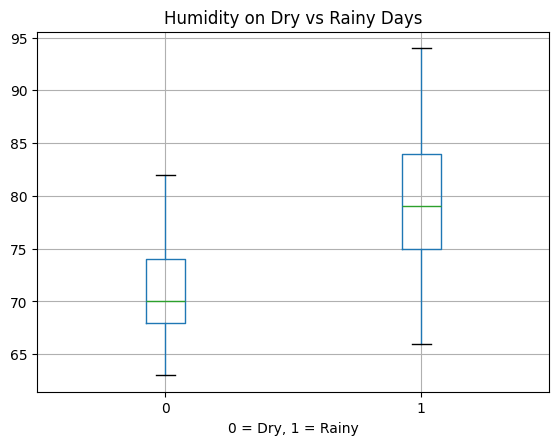

In [14]:
import matplotlib.pyplot as plt

df.boxplot(column='humidity', by='did_rain')
plt.title('Humidity on Dry vs Rainy Days')
plt.suptitle('')
plt.xlabel('0 = Dry, 1 = Rainy')
plt.show()

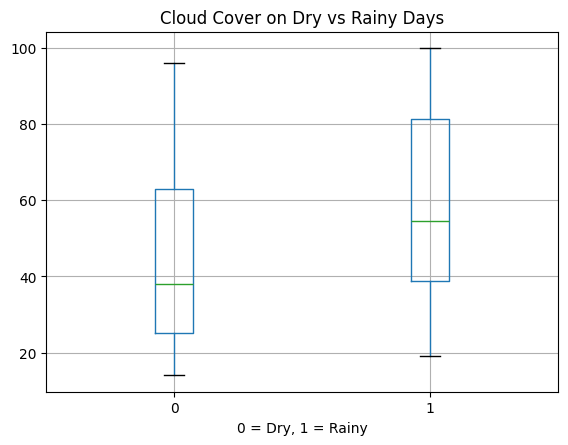

In [15]:
import matplotlib.pyplot as plt

df.boxplot(column='cloud_cover', by='did_rain')
plt.title('Cloud Cover on Dry vs Rainy Days')
plt.suptitle('')
plt.xlabel('0 = Dry, 1 = Rainy')
plt.show()

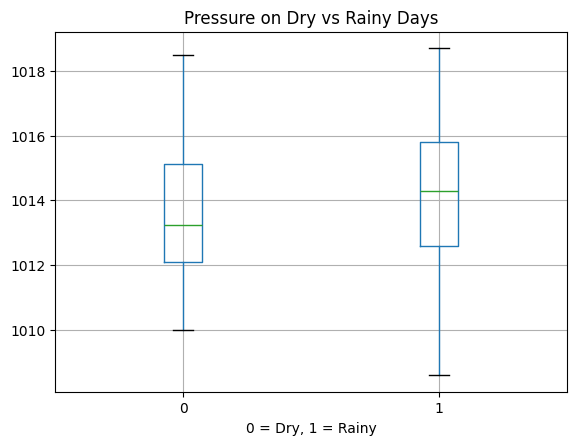

In [16]:
import matplotlib.pyplot as plt

df.boxplot(column='pressure', by='did_rain')
plt.title('Pressure on Dry vs Rainy Days')
plt.suptitle('')
plt.xlabel('0 = Dry, 1 = Rainy')
plt.show()

In [17]:
drop_cols = ['time', 'precip_sum', 'rain_sum', 'precip_hours']
X = df.drop(columns=drop_cols + ['did_rain'])
y = df['did_rain']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(280, 10) (70, 10)


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7571428571428571

Confusion Matrix:
 [[18  9]
 [ 8 35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.67      0.68        27
           1       0.80      0.81      0.80        43

    accuracy                           0.76        70
   macro avg       0.74      0.74      0.74        70
weighted avg       0.76      0.76      0.76        70



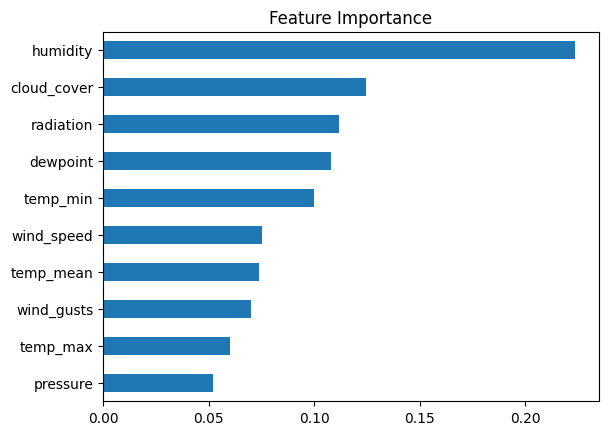

In [21]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()